# Task 3 — Data quality ed EDA

Controlli di qualita' (sezioni 1-2) e analisi esplorativa (3-6) su `training.csv`. Motivazioni:
`documentation/03_analisi_esplorativa.md`.

In [1]:
# L'EDA si fa su training.csv, cioe' sulla tabella per studente costruita dal Task 1:
# act-mooc grezzo e' un log di eventi e a livello studente non esiste nulla da esplorare
# finche' quella tabella non c'e'. Colori ed etichette sono fissati qui una volta sola,
# cosi' tutte le figure del task usano la stessa convenzione (blu = prosegue, rosso = abbandona).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)

COLORI = {0: "#4C72B0", 1: "#C44E52"}
ETICHETTE = {0: "prosegue", 1: "abbandona"}

training = pd.read_csv("../data/training.csv").set_index("USERID")
X = training.drop(columns="ABBANDONO")
y = training["ABBANDONO"]

print("dimensioni:", training.shape)
print("tipi      :", dict(training.dtypes.astype(str).value_counts()))
training.head()

dimensioni: (7035, 9)
tipi      : {'float64': np.int64(5), 'int64': np.int64(4)}


,n_azioni,n_attivita_distinte,n_giorni_attivi,durata_giorni,feature0_media,feature1_media,feature2_media,feature3_media,ABBANDONO
USERID,,,,,,,,,
0,75,23,12,27.340,-0.320,-0.063,0.080,2.159,0
1,25,14,4,10.771,-0.320,-0.130,0.087,0.013,0
2,188,71,10,25.965,0.232,0.079,-0.066,-0.040,0
3,5,5,2,8.553,-0.320,0.073,0.007,-0.067,1
4,8,7,1,0.019,-0.320,0.200,0.295,0.861,1


## 1. Statistiche descrittive

In [2]:
# Statistiche descrittive con in piu' l'ASIMMETRIA: e' l'indice che rivelera' le code
# pesanti di feature2_media e feature3_media (skew 54,8 e 16,1) e la non normalita' delle
# distribuzioni, cioe' la conferma indipendente della scelta fatta nel Task 2.1.
descrittive = training.describe().T
descrittive["skew"] = training.skew()
print(descrittive.round(3).to_string())

                      count    mean     std    min     25%     50%     75%      max    skew
n_azioni             7035.0  57.405  57.818  4.000  12.000  37.000  86.000  504.000   1.637
n_attivita_distinte  7035.0  24.835  20.519  1.000   7.000  18.000  38.000   95.000   0.940
n_giorni_attivi      7035.0   4.497   3.714  1.000   2.000   3.000   6.000   25.000   1.354
durata_giorni        7035.0  10.858   9.795  0.000   0.394   9.036  20.071   29.135   0.320
feature0_media       7035.0  -0.091   0.259 -0.320  -0.320  -0.155   0.048    3.384   1.868
feature1_media       7035.0  -0.054   0.300 -0.436  -0.365  -0.030   0.200    0.837   0.173
feature2_media       7035.0   0.023   0.294 -0.269  -0.051   0.003   0.072   20.488  54.819
feature3_media       7035.0  -0.002   0.213 -0.067  -0.067  -0.042   0.000    7.559  16.127
ABBANDONO            7035.0   0.577   0.494  0.000   0.000   1.000   1.000    1.000  -0.312


Nessun valore impossibile. `feature2_media` e `feature3_media` hanno asimmetria 54,8 e 16,1:
massimo 20,5 contro terzo quartile 0,07 — candidati a essere «osservazioni errate», li guardiamo al
punto 2.3.

## 2. Controlli di qualita'

Oltre ai controlli standard verifichiamo cinque **vincoli che devono valere per costruzione**: se
uno fallisse, ci sarebbe un errore nel preprocessing del Task 1.

In [3]:
print("valori mancanti      :", int(training.isna().sum().sum()))
print("USERID duplicati     :", int(training.index.duplicated().sum()))
print("righe duplicate      :", int(training.duplicated().sum()))

# ogni controllo e' gia' un'espressione su tutta la colonna: `.all()` riduce 7.035 confronti
# a un booleano, e la Serie li raccoglie tutti senza scorrerli uno a uno per stamparli
controlli = pd.Series({
    "n_attivita_distinte <= n_azioni": (X.n_attivita_distinte <= X.n_azioni).all(),
    "n_giorni_attivi <= n_azioni":     (X.n_giorni_attivi <= X.n_azioni).all(),
    "n_azioni >= 1":                   (X.n_azioni >= 1).all(),
    "durata_giorni >= 0":              (X.durata_giorni >= 0).all(),
    "durata_giorni <= 29.77 (finestra osservata)": (X.durata_giorni <= 29.77).all(),
    "n_giorni_attivi <= durata_giorni + 1": (X.n_giorni_attivi <= X.durata_giorni + 1).all(),
})
print()
print(controlli.map({True: "OK", False: "FALSO"}).to_string())

valori mancanti      : 0
USERID duplicati     : 0
righe duplicate      : 255

n_attivita_distinte <= n_azioni                   OK
n_giorni_attivi <= n_azioni                       OK
n_azioni >= 1                                     OK
durata_giorni >= 0                                OK
durata_giorni <= 29.77 (finestra osservata)       OK
n_giorni_attivi <= durata_giorni + 1           FALSO


### 2.2 Il vincolo che fallisce

`n_giorni_attivi` conta i giorni di **calendario** (`TIMESTAMP // 86400`), `durata_giorni` misura
max−min. Due azioni a cavallo della mezzanotte cadono in bucket diversi pur distando minuti.
Controlliamolo sui timestamp grezzi.

In [4]:
# Il sesto vincolo risulta falso in 392 righe. Non e' un errore: `n_giorni_attivi` conta i
# GIORNI DI CALENDARIO distinti (TIMESTAMP // 86400), mentre `durata_giorni` misura la
# distanza fra prima e ultima azione. Due azioni a cavallo della mezzanotte cadono in
# bucket diversi pur distando pochi minuti. Qui lo si verifica sui timestamp grezzi.
violazioni = training[X.n_giorni_attivi > X.durata_giorni + 1]
print(f"violazioni: {len(violazioni)} su {len(training)} ({len(violazioni)/len(training):.1%})")
print(violazioni[["n_azioni", "n_giorni_attivi", "durata_giorni"]].sort_values("durata_giorni").head(3).to_string())

import preprocessing as pp
azioni = pp.carica_azioni().sort_values(["USERID", "TIMESTAMP"], kind="stable")
storia = azioni.drop(index=azioni.groupby("USERID").tail(1).index)

esempio = violazioni.index[0]
s = storia[storia.USERID == esempio]
print(f"\nstudente {esempio}: TIMESTAMP = {[int(v) for v in s.TIMESTAMP]}")
print(f"  bucket giorno            = {sorted({int(v // 86400) for v in s.TIMESTAMP})}  -> n_giorni_attivi = {s.TIMESTAMP.pipe(lambda c: (c // 86400).nunique())}")
print(f"  (max - min) / 86400      = {(s.TIMESTAMP.max() - s.TIMESTAMP.min()) / 86400:.3f}  -> durata_giorni")

violazioni: 392 su 7035 (5.6%)
        n_azioni  n_giorni_attivi  durata_giorni
USERID                                          
6516          27                2          0.010
4973          12                2          0.011
2318          19                2          0.016



studente 9: TIMESTAMP = [38414, 122038, 122048, 122056, 122059]
  bucket giorno            = [0, 1]  -> n_giorni_attivi = 2
  (max - min) / 86400      = 0.968  -> durata_giorni


Non e' un errore: e' la definizione di «giorno». `n_giorni_attivi` dice **in quanti giorni di
calendario lo studente e' comparso**, non per quanti giorni e' rimasto attivo.

### 2.3 Duplicati e valori estremi

In [5]:
# Duplicati e valori estremi: entrambi vanno TENUTI. Le righe con profilo identico sono
# studenti diversi (USERID e' univoco) con storie brevissime, e rimuoverle toglierebbe
# soprattutto abbandoni, distorcendo il target; i valori estremi sono medie reali di
# studenti con molte azioni, non refusi.
duplicate = training[training.duplicated(keep=False)]
print(f"righe con profilo identico: {len(duplicate)}  (in {len(duplicate.drop_duplicates())} gruppi distinti)")
print(f"  n_azioni fra i duplicati: mediana {duplicate.n_azioni.median():.0f}, massimo {duplicate.n_azioni.max()}")
print(f"  n_azioni nel dataset    : mediana {X.n_azioni.median():.0f}, massimo {X.n_azioni.max()}")

asimmetriche = X[["feature2_media", "feature3_media"]]
print("\nvalori estremi delle due feature piu' asimmetriche:")
print(pd.DataFrame({"q99": asimmetriche.quantile(.99), "massimo": asimmetriche.max(),
                    "studenti oltre 1.0": (asimmetriche > 1).sum()}).round(3).to_string())

print("\ngli studenti con feature2_media > 1:")
print(training[X.feature2_media > 1][["n_azioni", "n_giorni_attivi", "feature2_media", "ABBANDONO"]].to_string())

righe con profilo identico: 358  (in 103 gruppi distinti)
  n_azioni fra i duplicati: mediana 5, massimo 9
  n_azioni nel dataset    : mediana 37, massimo 504

valori estremi delle due feature piu' asimmetriche:
                  q99  massimo  studenti oltre 1.0
feature2_media  0.329   20.488                   6
feature3_media  0.630    7.559                  39

gli studenti con feature2_media > 1:
        n_azioni  n_giorni_attivi  feature2_media  ABBANDONO
USERID                                                      
1443         181                7           2.756          0
1592           5                1           1.309          1
4150           8                1           1.359          1
5103          84                6          20.488          1
5871         168                7          10.479          0
5891           5                1           1.009          1


**Nessuna riga va rimossa.** I profili identici sono studenti diversi (`USERID` e' unico) con storie
brevissime: mediana 5 azioni contro 37. Rimuoverli toglierebbe quasi solo abbandoni e distorcerebbe
il target. I valori estremi sono medie su decine di azioni reali.

Per il Task 5: `StandardScaler` risente di code cosi' pesanti, va confrontato con uno scaler
resistente agli outlier.

## 3. Distribuzione della variabile target

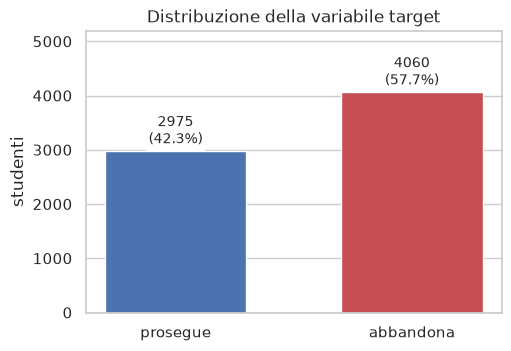

In [6]:
# Verifica grafica del bilanciamento: 57,7% contro 42,3%, nessun riequilibrio necessario.
fig, ax = plt.subplots(figsize=(5, 3.4), constrained_layout=True)
conteggi = y.value_counts().sort_index()
barre = ax.bar([ETICHETTE[k] for k in conteggi.index], conteggi.values,
               color=[COLORI[k] for k in conteggi.index], width=.6)
for b, v in zip(barre, conteggi.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 60, f"{v}\n({v / len(y):.1%})", ha="center", va="bottom",
            fontsize=10, bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none"))
ax.set_ylim(0, conteggi.max() * 1.28); ax.set_ylabel("studenti"); ax.grid(axis="x", visible=False)
ax.set_title("Distribuzione della variabile target")
plt.show()

57,7% contro 42,3%: quasi bilanciate. Lo sbilanciamento estremo del Task 1 (0,99%) esisteva solo a
livello azione.

## 4. Distribuzione delle feature

Un boxplot per classe, **una scala per riquadro** (le feature vanno da 504 a ~0) e outlier nascosti
dal disegno: schiaccerebbero i quartili, e li abbiamo gia' analizzati al punto 2.3.

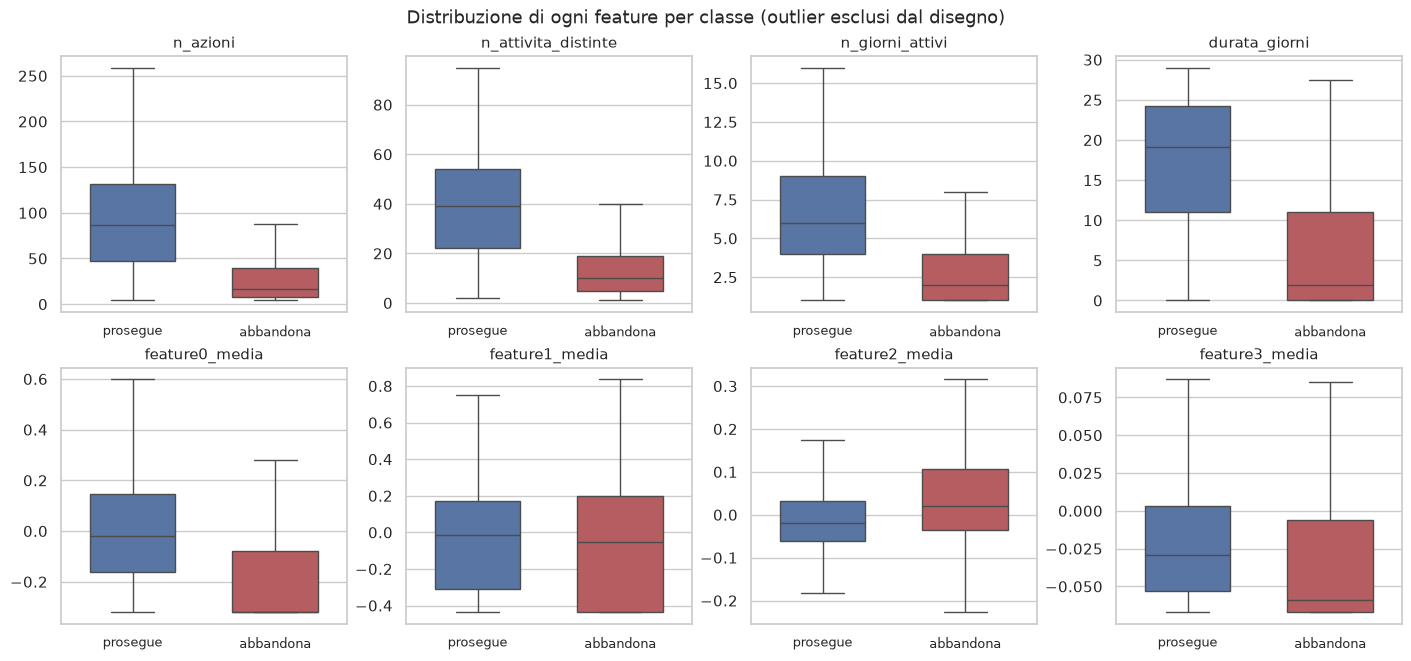

In [7]:
# Un boxplot per feature, ciascuno con la PROPRIA scala: si va da n_azioni fino a 504 a
# feature3_media intorno a 0, e una scala comune renderebbe illeggibili sette riquadri su
# otto. Outlier non disegnati perche' schiaccerebbero i quartili (sono analizzati sopra).
fig, axes = plt.subplots(2, 4, figsize=(14, 6.5), constrained_layout=True)
for ax, c in zip(axes.ravel(), X.columns):
    sns.boxplot(data=training, x="ABBANDONO", y=c, hue="ABBANDONO", ax=ax, showfliers=False,
                palette=COLORI, legend=False, width=.6)
    ax.set_title(c, fontsize=11); ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_xticks([0, 1]); ax.set_xticklabels([ETICHETTE[0], ETICHETTE[1]], fontsize=9)
fig.suptitle("Distribuzione di ogni feature per classe (outlier esclusi dal disegno)", fontsize=13)
plt.show()

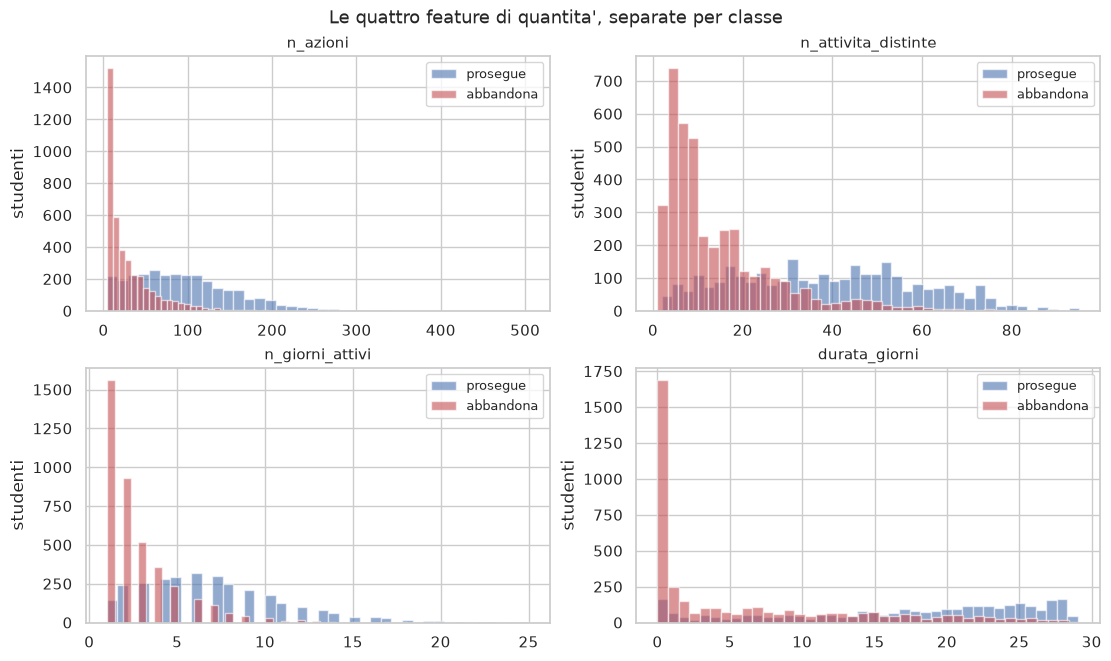

In [8]:
# Istogrammi delle sole quattro feature di quantita', dove la separazione fra classi si
# vede: durata_giorni e' bimodale (un picco a zero, uno oltre i 20 giorni), quindi le
# distribuzioni non sono normali — ed e' un argomento contro il Naive Bayes gaussiano.
QUANTITA = ["n_azioni", "n_attivita_distinte", "n_giorni_attivi", "durata_giorni"]
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), constrained_layout=True)
for ax, c in zip(axes.ravel(), QUANTITA):
    for k in (0, 1):
        ax.hist(X.loc[y == k, c], bins=40, alpha=.6, label=ETICHETTE[k], color=COLORI[k])
    ax.set_title(c, fontsize=11); ax.set_ylabel("studenti"); ax.legend(fontsize=9)
fig.suptitle("Le quattro feature di quantita', separate per classe", fontsize=13)
plt.show()

Le quattro feature di quantita' separano i gruppi, le `feature*_media` quasi no. Le distribuzioni
non sono normali: `durata_giorni` e' bimodale.

## 5. Perche' tre feature su otto sono inerti

La causa non e' nel nostro preprocessing: guardiamo le FEATURE **grezze** sulle 411.749 azioni.

          quota sul valore piu' frequente  valori distinti  dev.std
FEATURE0                            0.869               27      1.0
FEATURE1                            0.830               16      1.0
FEATURE2                            0.645               87      1.0
FEATURE3                            0.935              164      1.0


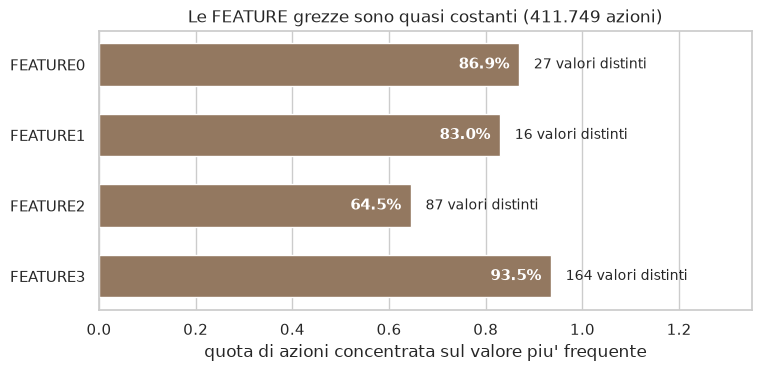

In [9]:
# Perche' tre feature su otto sono inerti: la causa sta nelle FEATURE GREZZE, non nel
# nostro preprocessing. Sono standardizzate (dev.std 1,000) ma quasi costanti — FEATURE3
# ha lo stesso valore nel 93,5% delle 411.749 azioni. La media di una variabile che non
# varia produce una feature che non varia.
GREZZE = ["FEATURE0", "FEATURE1", "FEATURE2", "FEATURE3"]
quota = {f: azioni[f].value_counts(normalize=True).iloc[0] for f in GREZZE}
distinti = {f: azioni[f].nunique() for f in GREZZE}

print(pd.DataFrame({"quota sul valore piu' frequente": quota,
                    "valori distinti": distinti,
                    "dev.std": {f: azioni[f].std() for f in GREZZE}}).round(3).to_string())

fig, ax = plt.subplots(figsize=(7.5, 3.6), constrained_layout=True)
nomi = GREZZE[::-1]
barre = ax.barh(nomi, [quota[f] for f in nomi], color="#937860", height=.6)
for b, f in zip(barre, nomi):
    centro = b.get_y() + b.get_height() / 2
    ax.text(quota[f] - .02, centro, f"{quota[f]:.1%}", va="center", ha="right",
            fontsize=11, color="white", fontweight="bold")
    ax.text(quota[f] + .03, centro, f"{distinti[f]} valori distinti", va="center", fontsize=10)
ax.set_xlim(0, 1.35); ax.set_xlabel("quota di azioni concentrata sul valore piu' frequente")
ax.grid(axis="y", visible=False)
ax.set_title("Le FEATURE grezze sono quasi costanti (411.749 azioni)")
plt.show()

Sono standardizzate ma quasi costanti. Fare la media di una variabile che non varia produce una
feature che non varia. Stessa causa per tre osservazioni fatte altrove: le correlazioni a zero del
Task 1, la varianza degenere del Task 2.1, il terzo di studenti al minimo di `feature0_media`.

## 6. Correlazioni

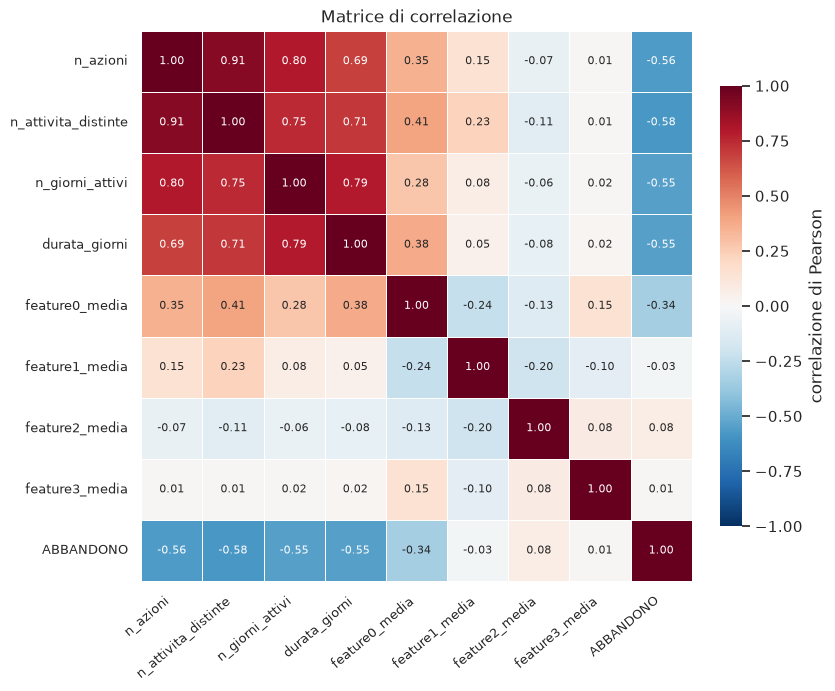

In [10]:
# Matrice di correlazione: da leggere in due direzioni. La colonna ABBANDONO dice quali
# feature portano segnale; il blocco delle quattro quantita' dice quanto si somiglino fra
# loro (fino a 0,91). E' da qui che nasce l'avvertenza del Task 5 sui coefficienti, che
# con collinearita' cosi' alta non sono interpretabili singolarmente.
fig, ax = plt.subplots(figsize=(8.2, 6.8), constrained_layout=True)
sns.heatmap(training.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=.5, ax=ax, annot_kws={"size": 8},
            cbar_kws={"shrink": .8, "label": "correlazione di Pearson"})
ax.set_title("Matrice di correlazione")
plt.setp(ax.get_xticklabels(), rotation=40, ha="right", fontsize=9)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.show()

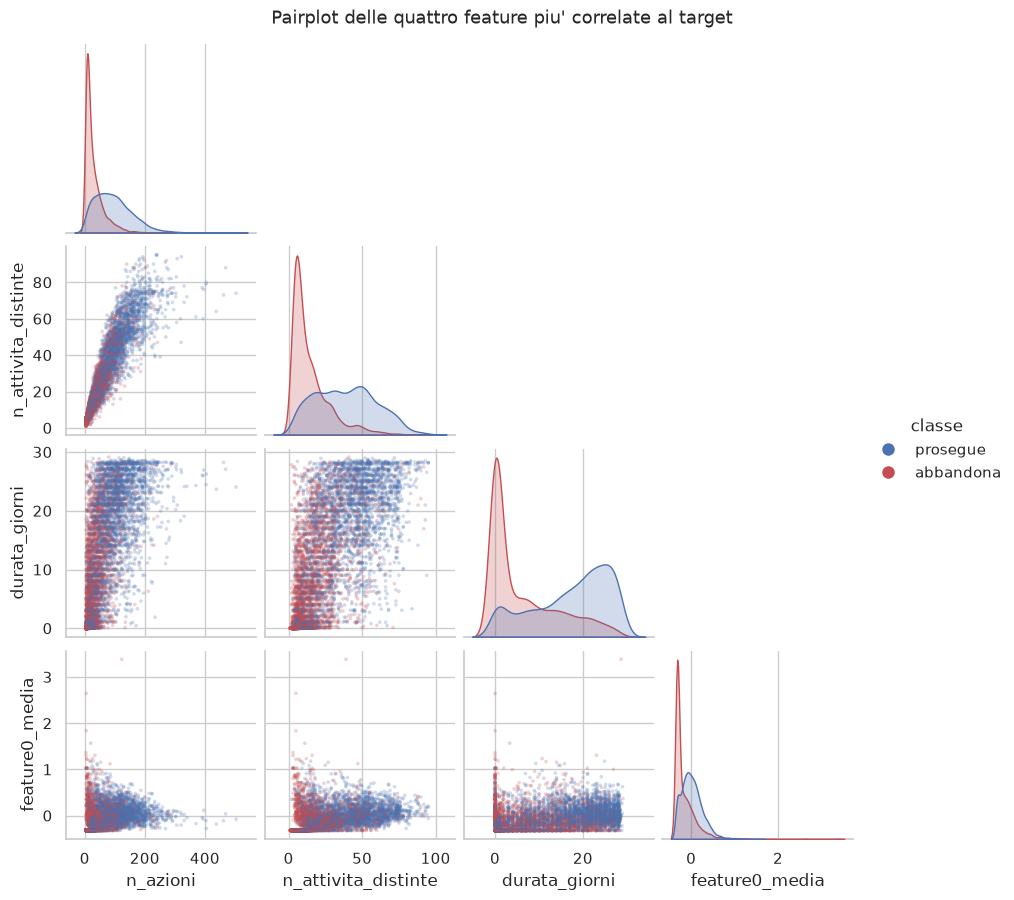

In [11]:
# Il pairplot mostra la stessa cosa geometricamente: le nuvole si separano lungo gli assi
# delle quantita' ma non lungo feature0_media, e il pannello n_azioni x n_attivita_distinte
# e' una striscia quasi rettilinea — cioe' le due feature dicono quasi la stessa cosa.
SCELTE = ["n_azioni", "n_attivita_distinte", "durata_giorni", "feature0_media"]
dati = training[SCELTE].assign(classe=y.map(ETICHETTE))
g = sns.pairplot(dati, hue="classe", corner=True,
                 palette={ETICHETTE[0]: COLORI[0], ETICHETTE[1]: COLORI[1]},
                 plot_kws={"s": 7, "alpha": .25, "edgecolor": "none"},
                 diag_kws={"common_norm": False}, height=2.2)
for handle in g.legend.legend_handles:       # la legenda ereditava alpha .25 e s=7
    handle.set_alpha(1); handle.set_markersize(9)
g.figure.suptitle("Pairplot delle quattro feature piu' correlate al target", y=1.02, fontsize=13)
plt.show()

Due blocchi: le quattro feature di quantita' correlate al target fra −0,55 e −0,58 e **fra loro fino
a 0,91**; le altre tre fra −0,03 e +0,08.

## 7. Cosa portiamo ai task successivi

- Nessuna osservazione errata, nessuna riga da rimuovere.
- **Collinearita' fino a 0,91**: i coefficienti di un modello lineare non saranno interpretabili
  singolarmente.
- **Tre feature su otto sono rumore**, per un difetto del dataset originale. Le teniamo: scartarle
  guardando questi dati sarebbe una scelta presa sul test.
- Distribuzioni asimmetriche: confrontare `StandardScaler` con uno scaler resistente agli outlier.